# Beyond TESS: Fitting ground-based follow-up of TESS targets

A single ground-based observation of one eclipse usually can't constrain a full eclipse model on
its own — there just aren't enough eclipses in one partial night to pin down the shape *and* the
timing simultaneously. `EBP_sweep` solves this by reusing the precise eclipse *shape*
(depth, duration, impact parameter) we already measured from pooled TESS data with the `batman`
method, and fitting *only* the timing to the new data:


In [1]:
tic_id = "TIC 343127696"

from EBP_sweep import read_global_eclipse_params

pri_params, sec_params = read_global_eclipse_params(tic_id)
pri_params

/Users/tunde/miniconda3/envs/ellc_env/lib/python3.10/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


{'t0': 1742.6799036767914+/-0.0001881572980729,
 'P': 4.672305635917415+/-5.809492262507478e-07,
 'rp': 0.5009315681100726+/-0.0007780467979336,
 'dur': 0.6377450925615288+/-0.0008849912309772,
 'b': 0.4046048826223457+/-0.0015150798586647,
 'u1': 0.8921733380875035+/-0.0551193963929205,
 'u2': -0.896782945506306+/-0.0934511797583935,
 'Aev': 0.0181275263875451+/-7.653665037818268e-05,
 'offset': -0.0128199307293591+/-0.0001105355930478,
 'slope': 7.022513466570235e-07+/-7.130450183738428e-08}

### Load MARVEL data

In [2]:
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

star = SkyCoord(ra=334.52585*u.deg, 
				dec=55.90433*u.deg, 
				frame='icrs')

observatory_location = EarthLocation.of_site('Roque de los Muchachos, La Palma')  

In [3]:
NIGHTS = [
    dict(label="2026-07-28", path="../../../MARVEL_data/TIC_343127696_V0743_Cep_webobs_20260728.txt",
	    ecl_type="sec", T_pred=2461249.5, err_scale=2.0, flux_floor=0.8),
	    
    dict(label="2026-08-11", path="../../../MARVEL_data/TIC_343127696_V0743_Cep_webobs_20260811.txt",
	    ecl_type="sec", T_pred=2461263.53, err_scale=1.0, flux_floor=0.8),
	    
    dict(label="2026-08-12", path="../../../MARVEL_data/TIC_343127696_V0743_Cep_webobs_20260812.txt",
	    ecl_type="pri", T_pred=2461265.75, err_scale=1.0, flux_floor=None),
]

	GLOBAL FIT: Fit succeeded.
	GLOBAL FIT: Fit succeeded.
	GLOBAL FIT: Fit succeeded.


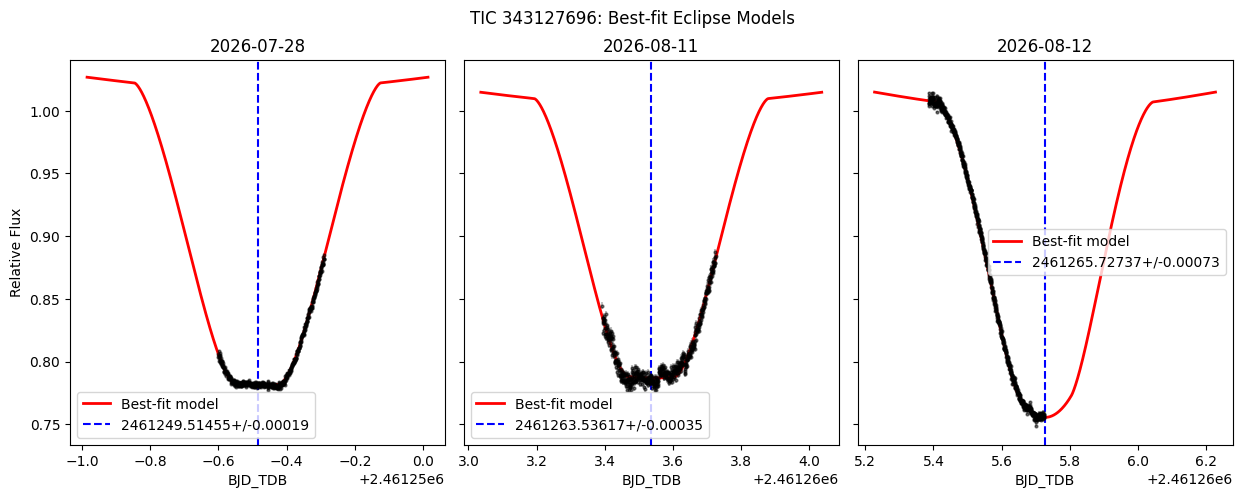

In [ ]:
from EBP_sweep.io import mag_to_flux
from EBP_sweep.batman_fit import fit_global_eclipse_shape, batman_flux_model
from uncertainties import ufloat
import warnings
warnings.filterwarnings("ignore")

# cycle through each night of observation
fig, axs = plt.subplots(1, len(NIGHTS), figsize=(15, 5), sharey=True)
axs[0].set_ylabel('Relative Flux')
fit_params = []
fit_models = []

for i,night in enumerate(NIGHTS):
	time, mag, mag_err = np.loadtxt( fname=night['path'], skiprows=7, delimiter=",",
									usecols=(1, 2, 3), unpack=True,  dtype=float)
	
	# Convert time form jd_utc to bjd_tdb
	t_ = Time(time, format='jd', scale='utc', location=observatory_location).tdb
	ltt = t_.light_travel_time(star, 'barycentric', ephemeris='builtin')
	time_bjd = (t_ + ltt).value

	#convert mag to flux
	flux, flux_err = mag_to_flux(mag, mag_err, nsim=1000)  # Convert magnitude and error to flux using Monte Carlo sampling
	flux, flux_err = flux / np.max(flux), flux_err / np.max(flux)   # Normalize flux and error to the maximum flux value

	# shift eclipse for bottom to be around depth observed in TESS light curve
	flux_bottom = 1 - sec_params["rp"].n**2 if night['ecl_type'] == 'sec' else 1 - pri_params["rp"].n**2
	flux = flux - flux.min() + flux_bottom 

	# Store the processed data back into the night dictionary
	night['time_bjd'] = time_bjd
	night['flux'] = flux
	night['flux_err'] = flux_err

	### fit the data using priors from the global fit
	pars = pri_params if night['ecl_type'] == 'pri' else sec_params
	fit_priors = dict(	t0 		= (night['T_pred']-0.1, night['T_pred'], night['T_pred']+0.1),
						offset 	= (-0.4,0,0.4),
						slope	= 0,
						P 		= pars['P'].n,
						rp 		= (pars['rp'].n, 5*pars['rp'].s),  # 5 x unc
						dur 	= (pars['dur'].n, 5*pars['dur'].s), # 1 x unc
						Aev 	= pars['Aev'].n,
						b 		= pars['b'].n,
						u1 		= (pars['u1'].n, pars['u1'].s),
						u2 		= (pars['u2'].n, pars['u2'].s),
						)

	fit_param, fit_model = fit_global_eclipse_shape(time_bjd, flux, flux_err, 
													param_priors=fit_priors, 
													return_model=True)
	fit_params.append(fit_param)
	fit_models.append(fit_model)
	smooth_time = np.linspace(fit_param['t0'].value - 0.5, fit_param['t0'].value + 0.5, 1000)
	bestfit_model = batman_flux_model(fit_model, fit_param, t=smooth_time)

	axs[i].errorbar(time_bjd, flux, yerr=flux_err, fmt='o', markersize=2, color='black', ecolor='gray', alpha=0.5)
	axs[i].plot(smooth_time, bestfit_model, color='red', lw=2, label='Best-fit model')
	axs[i].axvline(fit_param['t0'].value, color='blue', linestyle='--', label=f'{ufloat(fit_param["t0"].value, fit_param["t0"].stderr):.5f}')
	axs[i].legend()
	axs[i].set_title(night['label'])
	axs[i].set_xlabel('BJD_TDB')

plt.suptitle(f"TIC {tic_id[4:]}: Best-fit Eclipse Models")
plt.subplots_adjust(wspace=0.05)

In [11]:
fit_params[0]

name,value,standard error,relative error,initial value,min,max,vary
t0,2461249.51,1.8952e-04,(0.00%),2461249.5,2461249.40,2461249.60,True
P,4.67225898,0.00000000,(0.00%),4.672258976923193,-inf,inf,False
rp,0.48555046,0.00236174,(0.49%),0.4718148286448397,-inf,inf,True
dur,0.72201297,0.00418988,(0.58%),0.6884273017487973,-inf,inf,True
b,0.44542459,0.00000000,(0.00%),0.4454245881439782,-inf,inf,False
u1,-2.7635e-04,0.01052291,(3807.79%),7.235737342625724e-09,-inf,inf,True
u2,-0.04814879,0.03856162,(80.09%),0.096041370705884,-inf,inf,True
Aev,0.01328805,0.00000000,(0.00%),0.0132880490102728,-inf,inf,False
offset,0.02972763,0.00168870,(5.68%),0.0,-0.40000000,0.40000000,True
slope,0.00000000,0.00000000,,0.0,-inf,inf,False
